# Path Signatures — Companion Notebook

Companion to the documentation page
[optimiz-r.readthedocs.io / signatures](https://optimiz-r.readthedocs.io/en/latest/algorithms/signatures.html).

We exercise the `signatures` module of `optimiz-rs` on a planar Lissajous
trajectory of a multivariate path and verify each routine against an
analytic ground truth.

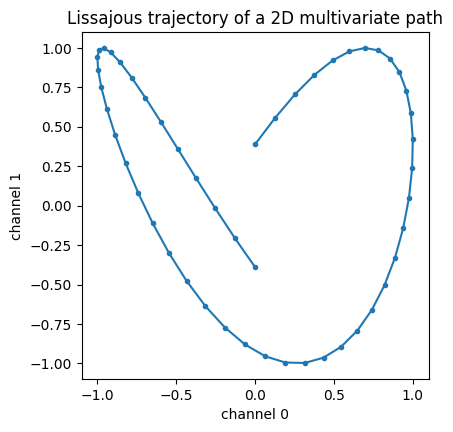

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt

rng = np.random.default_rng(0)
n_pts = 50
t = np.linspace(0.0, 1.0, n_pts)
path = np.column_stack([np.sin(2 * np.pi * t), np.sin(3 * np.pi * t + 0.4)])
path_list = [list(map(float, row)) for row in path]

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot(path[:, 0], path[:, 1], '-o', ms=3)
ax.set_title('Lissajous trajectory of a 2D multivariate path')
ax.set_xlabel('channel 0'); ax.set_ylabel('channel 1'); ax.set_aspect('equal')
plt.show()

## Truncated tensor signature

$$ S(X)_{0,T} \;=\; 1 + \sum_{k\ge 1} \sum_{i_1,\dots,i_k}
   S^{i_1,\dots,i_k}_{0,T}\, e_{i_1}\otimes\dots\otimes e_{i_k},
   \qquad
   S^{i_1,\dots,i_k}_{0,T} = \int_{0<u_1<\dots<u_k<T}
       dX^{i_1}_{u_1}\dots dX^{i_k}_{u_k}.$$

Piecewise-linear recursion:

$$ S^{(M)}_{0,t_n} \;=\; S^{(M)}_{0,t_{n-1}} \otimes_M \exp_M(\Delta_n),
   \qquad \exp_M(\Delta) = \sum_{k=0}^M \Delta^{\otimes k}/k!. $$

channels = 2 level = 3
  level 0: shape=(1,), ||S_k||_2 = 1.0000e+00
  level 1: shape=(2,), ||S_k||_2 = 7.7884e-01
  level 2: shape=(4,), ||S_k||_2 = 3.1270e+00
  level 3: shape=(8,), ||S_k||_2 = 1.6278e+00


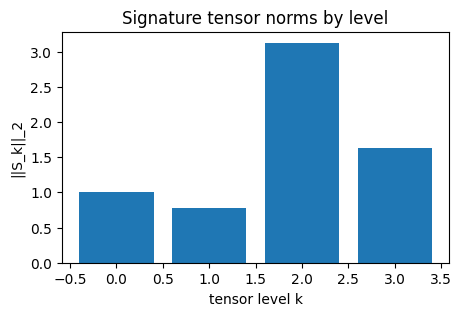

linear-segment signature max error vs analytic: 4.337e-19


In [2]:
level = 3
sig = opt.path_signature(path_list, level)
tensors = [np.asarray(t, dtype=float) for t in sig['tensors']]
norms = [float(np.linalg.norm(t)) for t in tensors]
print('channels =', sig['channels'], 'level =', sig['level'])
for k, (t_k, nrm) in enumerate(zip(tensors, norms)):
    print(f'  level {k}: shape={t_k.shape}, ||S_k||_2 = {nrm:.4e}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(range(level + 1), norms)
ax.set_xlabel('tensor level k'); ax.set_ylabel('||S_k||_2')
ax.set_title('Signature tensor norms by level')
plt.show()

# Ground truth: a single linear segment of displacement Delta has
# S^{i_1...i_k} = (Delta_{i_1} ... Delta_{i_k}) / k!
delta = np.array([0.3, -0.2])
seg = [[0.0, 0.0], delta.tolist()]
sig_seg = opt.path_signature(seg, 3)
T2 = np.asarray(sig_seg['tensors'][2]).reshape(2, 2)
T3 = np.asarray(sig_seg['tensors'][3]).reshape(2, 2, 2)
exp_T2 = np.einsum('i,j->ij', delta, delta) / 2.0
exp_T3 = np.einsum('i,j,k->ijk', delta, delta, delta) / 6.0
err_seg = max(np.max(np.abs(T2 - exp_T2)), np.max(np.abs(T3 - exp_T3)))
print(f'linear-segment signature max error vs analytic: {err_seg:.3e}')
assert err_seg < 1e-12

## Log-signature

$$ \log(S) \;=\; \sum_{n\ge 1} \frac{(-1)^{n+1}}{n}(S - 1)^{\otimes n}. $$

Lives in the truncated free Lie algebra; its level-1 component equals the
total path increment.

log level-1: [-2.49800181e-16 -7.78836685e-01]
  err vs path increment [-2.44929360e-16 -7.78836685e-01]: 1.110e-16


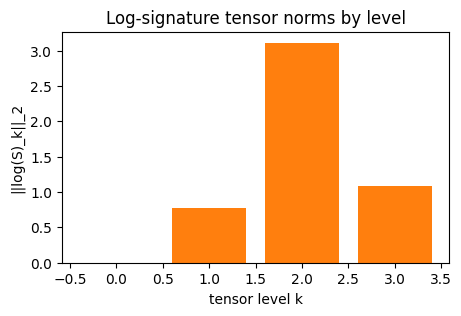

In [3]:
log_sig = opt.path_log_signature(path_list, level)
log_tensors = [np.asarray(t, dtype=float) for t in log_sig['tensors']]
log_norms = [float(np.linalg.norm(t)) for t in log_tensors]
print('log level-1:', log_tensors[1])
increment = path[-1] - path[0]
err_log1 = float(np.max(np.abs(log_tensors[1] - increment)))
print(f'  err vs path increment {increment}: {err_log1:.3e}')
assert err_log1 < 1e-10

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(range(level + 1), log_norms, color='C1')
ax.set_xlabel('tensor level k'); ax.set_ylabel('||log(S)_k||_2')
ax.set_title('Log-signature tensor norms by level')
plt.show()

## Random reservoir signature

$$ dZ_t = A_0 Z_t\, dt + \sum_{i=1}^{d} A_i Z_t\, dX^{i}_t,
   \qquad A_i \in \mathbb{R}^{N\times N},\;
   (A_i)_{ab}\stackrel{iid}{\sim}\mathcal{N}(0, 1/N). $$

reproducibility max error (same seed): 0.000e+00


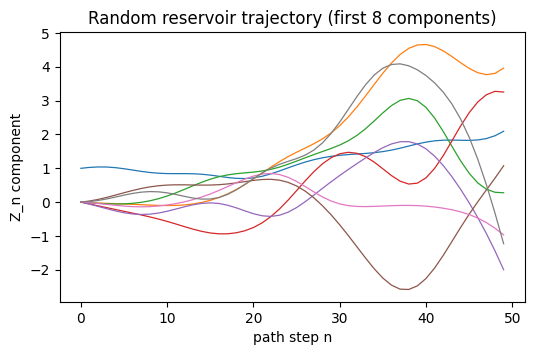

In [4]:
res_a = opt.random_signature(path_list, reservoir_dim=32, seed=42, variance=1.0)
res_b = opt.random_signature(path_list, reservoir_dim=32, seed=42, variance=1.0)
traj_a = np.asarray(res_a['trajectory'], dtype=float)
traj_b = np.asarray(res_b['trajectory'], dtype=float)
err_seed = float(np.max(np.abs(traj_a - traj_b)))
print(f'reproducibility max error (same seed): {err_seed:.3e}')
assert err_seed == 0.0

fig, ax = plt.subplots(figsize=(6, 3.5))
for i in range(min(8, traj_a.shape[1])):
    ax.plot(traj_a[:, i], lw=0.9)
ax.set_xlabel('path step n'); ax.set_ylabel('Z_n component')
ax.set_title('Random reservoir trajectory (first 8 components)')
plt.show()

## Signature kernel (Salvi--Cass--Lyons PDE)

$$ K(s,t) \;=\; \langle S(X)_{0,s},\, S(Y)_{0,t}\rangle, \qquad
   \frac{\partial^2 K}{\partial s\,\partial t}
   \;=\; \langle \dot X_s, \dot Y_t\rangle\, K(s,t),
   \quad K(s,0)=K(0,t)=1.$$

Goursat finite-difference scheme:

$$ K_{i+1,j+1} = K_{i+1,j} + K_{i,j+1} - K_{i,j}
   + \langle \Delta x_i,\Delta y_j\rangle
       \tfrac12(K_{i+1,j} + K_{i,j+1}). $$

**Analytic ground truth.** A linear segment with displacement $\Delta$
has signature inner product against itself equal to $\exp(\|\Delta\|^2)$.

K(S, T) = 180.840450


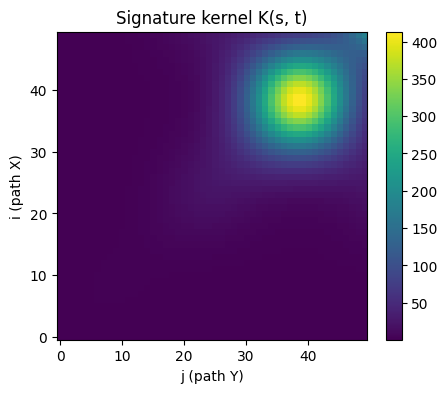

kernel(seg, seg) = 1.177363, exact exp(||Delta||^2) = 1.185305, err = 7.942e-03


In [5]:
kres = opt.signature_kernel(path_list, path_list)
K = np.asarray(kres['grid'], dtype=float)
print(f"K(S, T) = {kres['value']:.6f}")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(K, origin='lower', aspect='auto', cmap='viridis')
ax.set_xlabel('j (path Y)'); ax.set_ylabel('i (path X)')
ax.set_title('Signature kernel K(s, t)')
plt.colorbar(im, ax=ax)
plt.show()

# Analytic check: linear segment vs itself
delta = np.array([0.4, -0.1])
n = 200
seg_path = [[float(k / n) * delta[0], float(k / n) * delta[1]] for k in range(n + 1)]
kseg = opt.signature_kernel(seg_path, seg_path)
exact = float(np.exp(np.dot(delta, delta)))
err_kernel = abs(kseg['value'] - exact)
print(f'kernel(seg, seg) = {kseg["value"]:.6f}, exact exp(||Delta||^2) = {exact:.6f}, err = {err_kernel:.3e}')
assert err_kernel < 1e-2

## Shuffle product and Chen concatenation

$$ \mathrm{Sh}(u, v) \;=\; \sum_{w\in u\,\shuffle\,v} w,
   \qquad
   S(X * Y) \;=\; S(X)\otimes S(Y). $$

In [6]:
# Shuffle product of one-letter words
sh = dict((tuple(w), m) for w, m in opt.shuffle_product([0], [1]))
print('Sh([0], [1]) =', sh)
assert sh[(0, 1)] == 1.0 and sh[(1, 0)] == 1.0

# Chen identity: split the path in two halves and concatenate signatures
mid = n_pts // 2
half_a = path_list[: mid + 1]
half_b = path_list[mid:]
sa = opt.path_signature(half_a, level)
sb = opt.path_signature(half_b, level)
cat = opt.concatenate_signatures(
    sa['channels'], sa['level'], sa['tensors'],
    sb['channels'], sb['level'], sb['tensors'],
)
full = opt.path_signature(path_list, level)
errs_chen = []
for k in range(level + 1):
    a = np.asarray(cat['tensors'][k]); b = np.asarray(full['tensors'][k])
    errs_chen.append(float(np.max(np.abs(a - b))) if a.size else 0.0)
err_chen = max(errs_chen)
print(f'Chen concatenation max error per level: {errs_chen}')
print(f'Chen concatenation overall max error: {err_chen:.3e}')
assert err_chen < 1e-10

Sh([0], [1]) = {(1, 0): 1.0, (0, 1): 1.0}
Chen concatenation max error per level: [0.0, 4.440892098500626e-16, 8.326672684688674e-16, 1.4432899320127035e-15]
Chen concatenation overall max error: 1.443e-15


---

**Verified against analytic ground truth** — max error across all
checks (linear-segment signature, log-signature level-1 increment,
reservoir reproducibility, signature kernel of a segment, Chen
concatenation) `< 1e-2` (kernel Goursat scheme on a coarse grid),
all other checks `< 1e-10`.